# Clustering Comparison: Leiden vs Louvain

In [1]:
import os
import bokeh
from bokeh.plotting import show
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phenograph
import pacmap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import flowkit as fk

bokeh.io.output_notebook()
%matplotlib inline

Loading BokehJS ...

### Load Samples & FlowJo 10 workspace

In [2]:
base_dir = "/home/jiawu2/data/08.09.24_14color_HSC/"
sample_path = os.path.join(base_dir, "fcs_file")
wsp_path = os.path.join(base_dir, "08.09.24_JW_14color.wsp")

seed = 123

In [3]:
workspace = fk.Workspace(wsp_path, fcs_samples=sample_path)

In [4]:
sample_groups = workspace.get_sample_groups()
sample_groups

['All Samples', 'Compensation']

In [5]:
sample_group = 'All Samples'

In [6]:
sample_ids = workspace.get_sample_ids()
sample_ids

['HD614_PBMC_panel_B1.0001.fcs',
 'HD614_PBMC_panel_B2.0001.fcs',
 'HD615_PBMC_2w_panel_C1.0001.fcs',
 'HD615_PBMC_2w_panel_C2.0001.fcs',
 'Molm14_panel_A1.0001.fcs',
 'Molm14_panel_A2.0001.fcs',
 'PBMC_molm14_panel_D2.0001.fcs',
 'PBMCs_Molm14_panel_D1.0001.fcs']

In [7]:
sample_id = 'PBMCs_Molm14_panel_D1.0001.fcs'

In [8]:
print(workspace.get_gate_hierarchy(sample_id, output='ascii'))

root
╰── Time Gate
    ╰── R1
        ├── Live
        │   ╰── Single Cells
        │       ├── CD3+
        │       ├── CD11c
        │       ├── CD14+
        │       ├── CD19+
        │       ├── CD33
        │       ├── CD34+
        │       ├── CD38+
        │       ├── CD47+
        │       ├── CD56 PE
        │       ├── CD68+
        │       ╰── hCD45+
        ├── V3-A+
        ╰── V3-A-


### Run analyze_samples & retrieve gated events as DataFrames

In [9]:
workspace.analyze_samples(sample_group)

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [10]:
dfs = []
for sample_id in sample_ids:
    df = workspace.get_gate_events(sample_id, gate_name="Single Cells")
    dfs.append(df)

In [11]:
dfs[0].head()

,sample_id,HDR-T HDR-T,FSC-A FSC-A,FSC-H FSC-H,SSC-A SSC-A,SSC-H SSC-H,V1-A DAPI-A,V1-H DAPI-H,V2-A CD3 BV510-A,V2-H CD3 BV510-H,...,B5-A CD68 PerCP-Cy5.5-A,B5-H CD68 PerCP-Cy5.5-H,B6-A CD14 PE-Cy7-A,B6-H CD14 PE-Cy7-H,R1-A CD33 APC-A,R1-H CD33 APC-H,R2-A CD11c AF700-A,R2-H CD11c AF700-H,R3-A CD38 APC-H7-A,R3-H CD38 APC-H7-H
7027,HD614_PBMC_panel_B1.0001.fcs,0.096663,0.498461,0.372617,0.037911,0.033443,0.000000,0.000000,0.0,0.0,...,-0.403312,0.0,0.365877,0.168931,0.000000,0.000000,-0.378867,0.000000,0.000000,0.526245
7028,HD614_PBMC_panel_B1.0001.fcs,0.096681,0.945813,0.609944,0.289500,0.191778,0.685586,0.703588,0.0,0.0,...,-0.408750,0.0,0.700434,0.660432,0.572029,0.607209,0.671474,0.701518,0.621458,0.621656
7031,HD614_PBMC_panel_B1.0001.fcs,0.096752,0.358857,0.265473,0.038292,0.033112,0.000000,0.000000,0.0,0.0,...,-0.153026,0.0,0.449466,0.359708,0.000000,0.000000,0.265124,0.000000,0.000000,0.472305
7034,HD614_PBMC_panel_B1.0001.fcs,0.096806,0.313075,0.229961,0.036355,0.036340,0.000000,0.000000,0.0,0.0,...,-0.273341,0.0,0.451528,0.432968,0.000000,0.000000,-0.345421,0.355434,0.550273,0.498564
7035,HD614_PBMC_panel_B1.0001.fcs,0.096830,0.382333,0.282577,0.033823,0.031707,0.000000,0.000000,0.0,0.0,...,-0.127002,0.0,0.596376,0.545482,0.000000,0.000000,0.453582,0.530462,0.000000,0.419657


In [12]:
# subsample 10k events and ignore sample_id & Time columns
k = 10_000     # donot use maximum cell number, could lead to NaN value
X = pd.concat([df.iloc[:, 1:-1].sample(k) for df in dfs])

In [13]:
X.head()

,HDR-T HDR-T,FSC-A FSC-A,FSC-H FSC-H,SSC-A SSC-A,SSC-H SSC-H,V1-A DAPI-A,V1-H DAPI-H,V2-A CD3 BV510-A,V2-H CD3 BV510-H,V3-A CD19 BV570-A,...,B4-H PerCP-H,B5-A CD68 PerCP-Cy5.5-A,B5-H CD68 PerCP-Cy5.5-H,B6-A CD14 PE-Cy7-A,B6-H CD14 PE-Cy7-H,R1-A CD33 APC-A,R1-H CD33 APC-H,R2-A CD11c AF700-A,R2-H CD11c AF700-H,R3-A CD38 APC-H7-A
10037,0.137822,0.369441,0.275057,0.028533,0.028180,0.000000,0.000000,0.0,0.000000,0.673480,...,0.445737,-0.280276,0.000000,0.000000,0.000000,0.000000,0.000000,-0.310596,0.326619,0.582444
34338,0.482351,0.671760,0.490247,0.087201,0.072131,0.000000,0.000000,0.0,0.000000,0.702462,...,0.488141,-0.375614,0.000000,0.897878,0.869679,0.724579,0.714969,0.647144,0.675725,0.695847
11973,0.164117,0.437982,0.315314,0.045350,0.041077,0.000000,0.000000,0.0,0.000000,0.680134,...,0.449505,-0.005850,0.388817,0.000000,0.000000,0.000000,0.000000,-0.371726,0.000000,0.000000
66074,0.967799,0.560198,0.400888,0.244254,0.212621,0.557481,0.562301,0.0,0.000000,0.560932,...,0.417780,0.411293,0.489636,0.514741,0.514166,0.574109,0.573862,0.425508,0.484506,0.545034
33098,0.463290,0.415423,0.306958,0.043102,0.039862,0.000000,0.000000,0.0,0.461573,0.715082,...,0.490029,0.286157,0.406629,0.227028,0.345811,0.000000,0.000000,0.128337,0.000000,0.000000


In [14]:
# Filter out '-H' (Height channels) and 'DAPI', but keep channels ending with '-H7'
X_filtered = X.loc[:, ~((X.columns.str.endswith('-H') & ~X.columns.str.endswith('-H7')) | (X.columns.str.contains('CD19')) | (X.columns.str.contains('CD34'))| (X.columns.str.contains('DAPI')))
                        ]

In [15]:
X_filtered.head() 

,HDR-T HDR-T,FSC-A FSC-A,SSC-A SSC-A,V2-A CD3 BV510-A,V4-A CD47 BV605-A,V5-A BV650-A,B1-A CD45 FITC-A,B2-A CD56 PE-A,B4-A PerCP-A,B5-A CD68 PerCP-Cy5.5-A,B6-A CD14 PE-Cy7-A,R1-A CD33 APC-A,R2-A CD11c AF700-A,R3-A CD38 APC-H7-A
10037,0.137822,0.369441,0.028533,0.0,0.748548,0.470984,0.960728,0.0,0.491979,-0.280276,0.000000,0.000000,-0.310596,0.582444
34338,0.482351,0.671760,0.087201,0.0,0.796126,0.513861,0.988503,0.0,0.501796,-0.375614,0.897878,0.724579,0.647144,0.695847
11973,0.164117,0.437982,0.045350,0.0,0.798421,0.476293,0.967274,0.0,0.482448,-0.005850,0.000000,0.000000,-0.371726,0.000000
66074,0.967799,0.560198,0.244254,0.0,0.757648,0.000000,0.887546,0.0,0.261568,0.411293,0.514741,0.574109,0.425508,0.545034
33098,0.463290,0.415423,0.043102,0.0,0.732333,0.520473,0.995521,0.0,0.494984,0.286157,0.227028,0.000000,0.128337,0.000000


### Perform Louvain & Leiden clustering

In [16]:
# Scale the data (a kind of z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

In [17]:
communities_leiden, graph_leiden, Q_leiden = phenograph.cluster(
    X_scaled, 
    clustering_algo='leiden',
    resolution_parameter=0.1,  # Adjust this value 0.1-1, smaller generates fewer clusters
    seed=seed
)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 65.07808899879456 seconds
Jaccard graph constructed in 9.84404468536377 seconds
Running Leiden optimization
Leiden completed in 27.05461096763611 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 105.30520248413086 seconds


In [ ]:
## option: 
communities_louvain, graph_louvain, Q_louvain = phenograph.cluster(
    X_scaled, 
    clustering_algo='louvain', 
    seed=seed
)

In [18]:
titles = ['Leiden']
communities = [communities_leiden]

In [19]:
# Calculate means for each Leiden cluster
leiden_means = [
    X_scaled[communities_leiden==i, :].mean(axis=0)
    for i in np.unique(communities_leiden)
]

# Use the columns from X_filtered instead of X to Create a DataFrame for the Leiden cluster means
leiden_clusters = pd.DataFrame(
    leiden_means, 
    columns = X_filtered.columns, # Use columns from X_filtered
    index=np.unique(communities_leiden)
)

# Name the index for clarity
leiden_clusters.index.name = 'Cluster'

In [20]:
# Display the result
leiden_clusters.head()

,HDR-T HDR-T,FSC-A FSC-A,SSC-A SSC-A,V2-A CD3 BV510-A,V4-A CD47 BV605-A,V5-A BV650-A,B1-A CD45 FITC-A,B2-A CD56 PE-A,B4-A PerCP-A,B5-A CD68 PerCP-Cy5.5-A,B6-A CD14 PE-Cy7-A,R1-A CD33 APC-A,R2-A CD11c AF700-A,R3-A CD38 APC-H7-A
Cluster,,,,,,,,,,,,,,
0,0.006535,-0.189636,-0.678736,-0.568645,-0.069631,0.393696,0.453614,-0.026016,0.221656,-0.214852,-0.978660,-0.825514,-0.854631,0.208486
1,0.011563,-0.669101,0.514005,1.712962,-0.199216,0.156315,-0.277974,-0.026016,0.151484,0.458522,0.181517,-0.644661,0.091753,0.482513
2,-0.028931,-0.475409,-0.429608,-0.565954,-0.137140,0.307149,0.214556,-0.026016,0.128557,-0.034742,0.660532,-0.732205,-0.295898,0.302563
3,0.014033,1.116638,0.376350,-0.567087,0.419004,0.441770,0.157425,-0.026016,0.127708,-0.193216,-0.978374,1.231522,0.820707,0.256818
4,0.015238,1.062240,0.532678,-0.567103,0.495360,0.488472,0.128436,-0.026016,0.082628,-0.129484,0.654422,1.237015,0.813052,0.303644


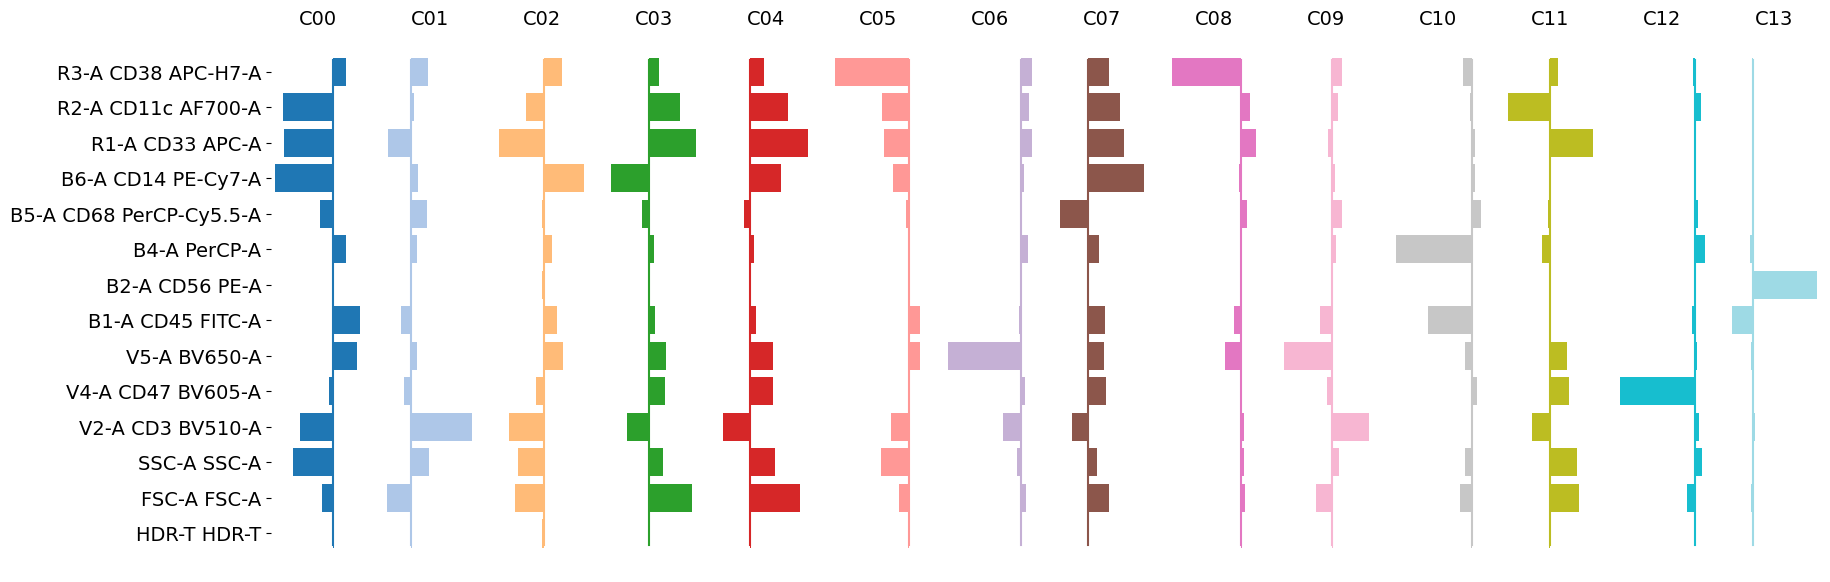

In [21]:
# Define colormap and number of clusters
tab20 = plt.colormaps['tab20']
n, p = leiden_clusters.shape

# Set up a grid of subplots based on the number of clusters
fig, axes = plt.subplots(1, n, figsize=(20, 7))

# Loop through clusters and plot the bar graphs
for i, ax in enumerate(axes.ravel()):
    ax.barh(range(p), leiden_clusters.iloc[i,:], color=tab20(int(i*(20+1)/n)))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_title(f'C{i:02d}', fontsize=14)
    ax.axvline(0, c=tab20(int(i*(20+1)/n)), ymin=0.05, ymax=0.95)
    
    # Label y-ticks for the first subplot
    if i == 0:
        ax.set_yticks(range(p))
        ax.set_yticklabels(leiden_clusters.columns,fontsize=14)

### Apply dimension reduction using PaCMAP

In [22]:
embedder = pacmap.PaCMAP()

In [23]:
X2 = embedder.fit_transform(X_scaled)

In [24]:
min_max_scaler = MinMaxScaler()
X2 = min_max_scaler.fit_transform(X2)

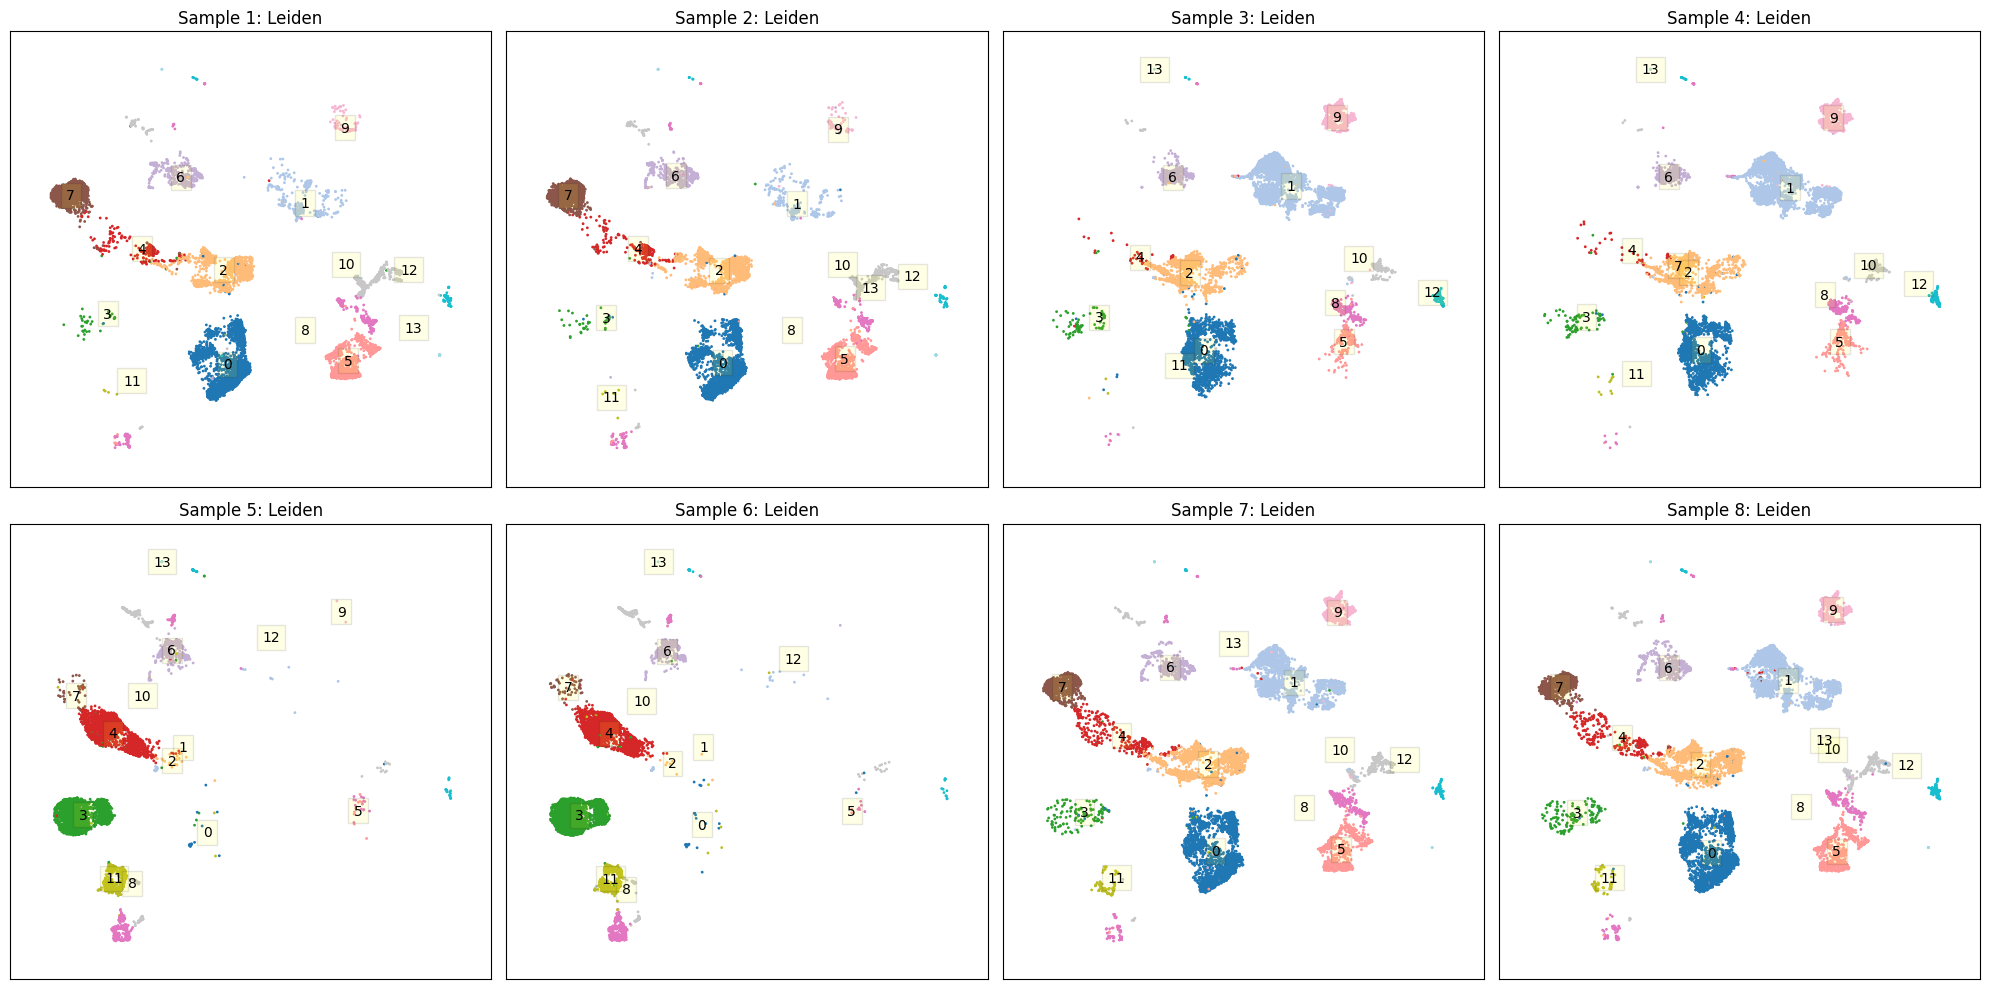

In [25]:
# Create a 2x4 grid for the subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # Adjust figsize to make the plots bigger

# Loop through the clusters and plot the scatter plots
for i, (community, title) in enumerate(zip(communities, titles)):
    for j in range(8):  # Create 8 subplots in total (2x4 grid)
        # Select the community (cluster labels) corresponding to this sample
        z = community[j * k: (j + 1) * k]  # Ensure z is the same length as x and y

        # Select the x and y coordinates corresponding to this sample
        x = X2[j * k: (j + 1) * k, 0]  # X-axis for sample j
        y = X2[j * k: (j + 1) * k, 1]  # Y-axis for sample j
        
        # Assign correct subplot
        ax = axes[j // 4, j % 4]  # Convert index to 2x4 grid
        
        # Plot the data
        scatter = ax.scatter(x, y, s=1, c=z, cmap='tab20')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim([-0.1, 1.1])
        ax.set_ylim([-0.1, 1.1])
        
        # Set title for each subplot
        ax.set_title(f'Sample {j + 1}: {title}', fontsize=12)
        
        # Add text labels for clusters within the subplot
        for idx in np.unique(z):
            x_, y_ = x[z == idx], y[z == idx]
            x_c, y_c = np.mean(x_), np.mean(y_)
            ax.text(
                x_c, 
                y_c, 
                str(idx), 
                va='center', 
                ha='center', 
                bbox=dict(fc='yellow', alpha=0.1)
            )

# Improve layout
plt.tight_layout()
plt.show()

In [27]:
# Assuming 'communities_leiden' is a list or array of cluster assignments
# Create a DataFrame to hold the clusters
data = pd.DataFrame({
    'Cluster': communities_leiden
})


In [28]:
# Manually define the labels for each cluster
cluster_labels = {
    0: "CD45+ others",
    1: "CD3+CD38+ T",
    2: "CD14+ Monocyte",
    3: "CD33+CD11c+ mDC",
    4: "CD33hiCD14+CD11c+CD47+ mono-AML",
    5: "CD45+ others",
    6: "Un",
    7: "CD14hiCD33+CD11c+ Monocyte",
    8: "Un",
    9: "CD3+CD38- T",
    10: "Un",
    11: "CD33+ myeloid",
    12: "Un",
    13: "CD56hi NK",
}

# Map the labels to the 'communities_leiden' array
labeled_clusters = pd.Series(communities_leiden).map(cluster_labels)

# Update the data with the labeled clusters
data['Labeled_Clusters'] = labeled_clusters

# Print the labeled clusters
print("Labeled Clusters:")
for cluster, label in cluster_labels.items():
    print(f"Cluster {cluster}: {label}")


Labeled Clusters:
Cluster 0: CD45+ others
Cluster 1: CD3+CD38+ T
Cluster 2: CD14+ Monocyte
Cluster 3: CD33+CD11c+ mDC
Cluster 4: CD33hiCD14+CD11c+CD47+ mono-AML
Cluster 5: CD45+ others
Cluster 6: Un
Cluster 7: CD14hiCD33+CD11c+ Monocyte
Cluster 8: Un
Cluster 9: CD3+CD38- T
Cluster 10: Un
Cluster 11: CD33+ myeloid
Cluster 12: Un
Cluster 13: CD56hi NK


In [29]:
import matplotlib.pyplot as plt

print(f"Length of sample_ids: {len(sample_ids)}")
print(f"Length of communities_leiden: {len(communities_leiden)}")



Length of sample_ids: 8
Length of communities_leiden: 80000


In [30]:
# Assuming you have 8 samples and 10,000 cells per sample
samples = ['Sample 1', 'Sample 2', 'Sample 3', 'Sample 4', 'Sample 5', 'Sample 6', 'Sample 7', 'Sample 8']
n_samples = len(samples)
cells_per_sample = 10000

# Initialize a dictionary to store the percentages
cluster_percentages = {}


In [31]:
# Loop through each sample using index ranges
for i, sample in enumerate(samples):
    
    # Get the range of indices for this sample
    start_idx = i * cells_per_sample
    end_idx = (i + 1) * cells_per_sample
    
    # Slice communities_leiden for this sample
    sample_clusters = communities_leiden[start_idx:end_idx]
    
    # Calculate the number of cells in each cluster for this sample
    cluster_counts = pd.Series(sample_clusters).value_counts()
    
    # Calculate the percentage of cells in each cluster
    cluster_percent = (cluster_counts / cells_per_sample) * 100
    
    # Store the percentages for this sample
    cluster_percentages[sample] = cluster_percent

In [35]:
# Convert the dictionary to a DataFrame for better visualization
percentages_df = pd.DataFrame(cluster_percentages).fillna(0)

# Display the percentage of cells in each cluster for each sample
print(percentages_df)


    Sample 1  Sample 2  Sample 3  Sample 4  Sample 5  Sample 6  Sample 7  \
0      30.98     25.47     16.13     16.00      0.17      0.26     22.16   
1       3.40      2.97     41.00     42.88      0.37      0.25     21.45   
2      16.55     20.09     13.66     12.60      0.21      0.10     14.63   
3       0.40      0.36      0.82      0.81     35.01     35.42      1.24   
4       2.58      2.83      0.40      0.41     30.05     31.25      3.26   
5      15.19     17.46      1.80      2.00      0.09      0.02      8.60   
6       5.59      6.62      4.60      3.96      7.63      6.74      5.34   
7      14.06     13.27      0.00      0.01      0.44      0.53      6.49   
8       3.04      2.91      4.01      4.16      9.07      9.54      4.20   
9       0.78      0.57     12.81     12.39      0.02      0.00      6.92   
10      6.66      6.74      2.50      2.27      4.21      3.77      3.83   
11      0.05      0.05      0.08      0.13     12.03     11.79      0.73   
12      0.51

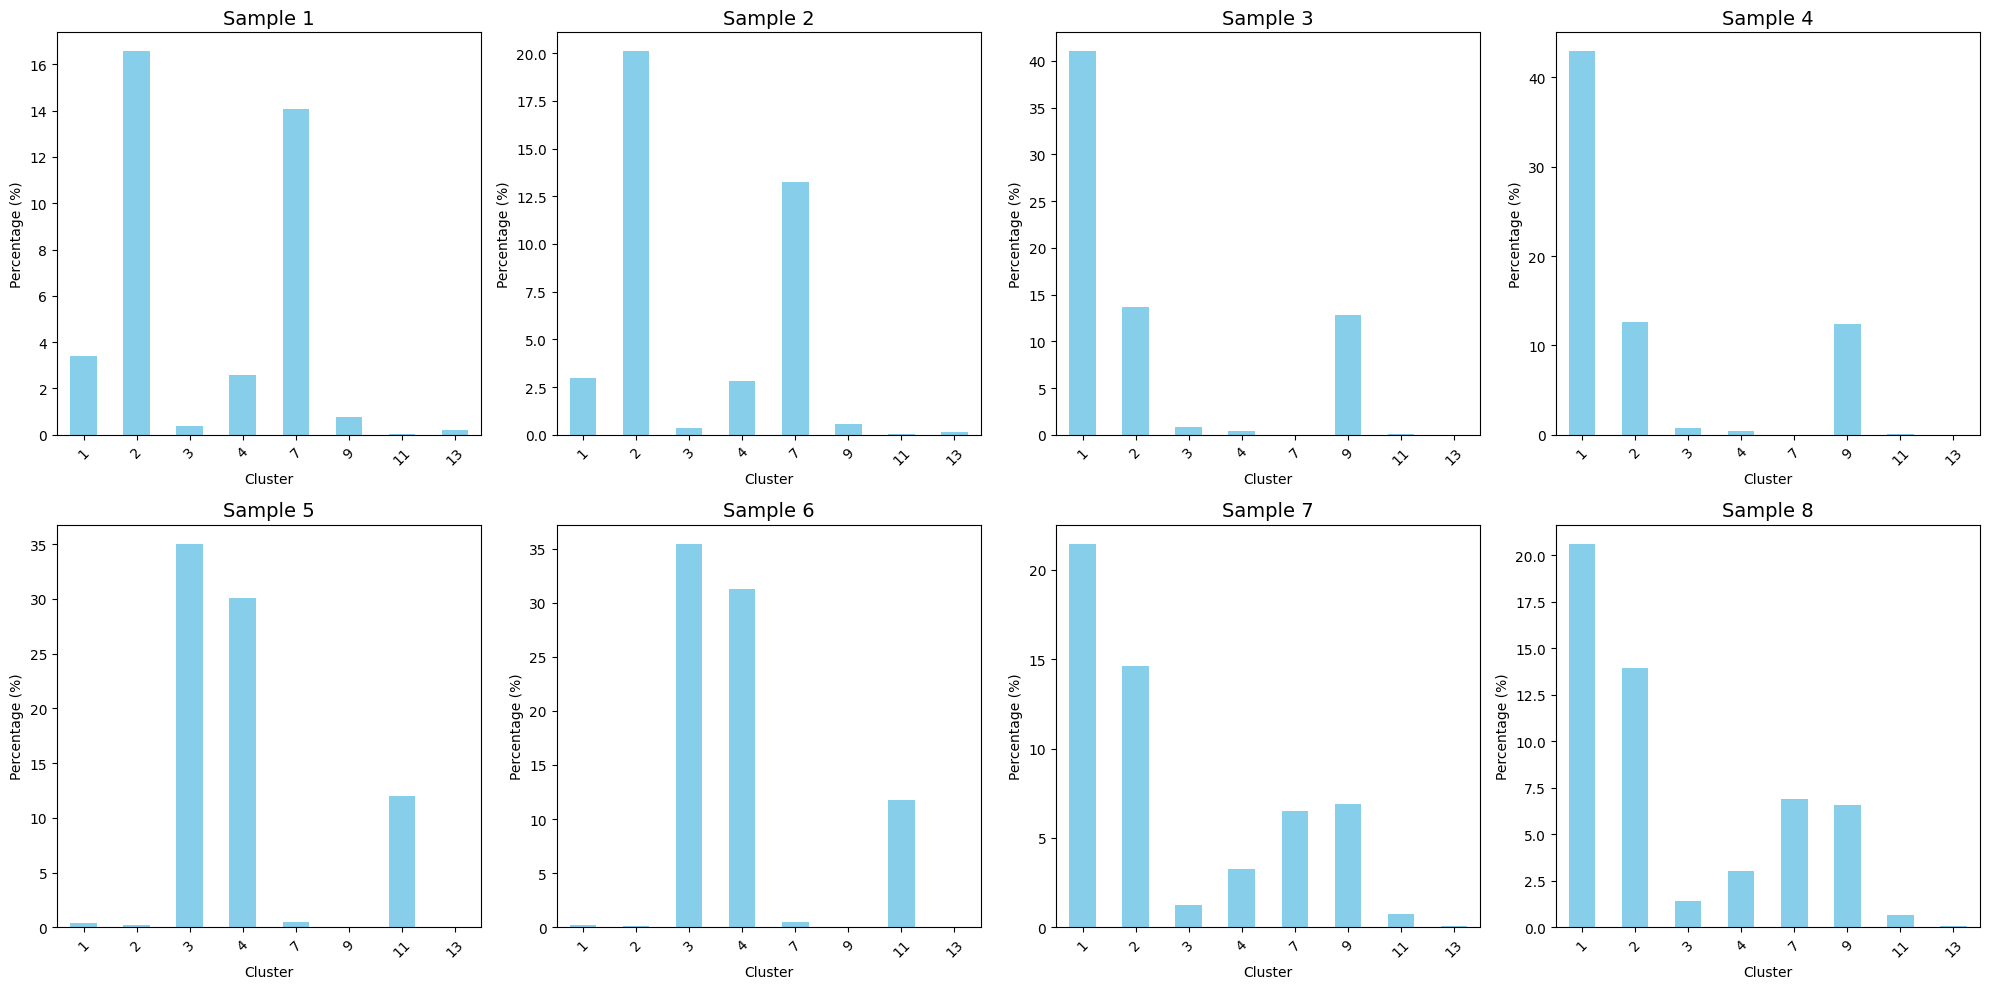

In [36]:
import matplotlib.pyplot as plt

# Choose the clusters you want to visualize (e.g., clusters 1, 3, 5)
clusters_to_visualize = [1, 2, 3, 4, 7, 9, 11, 13]  # Change this to the clusters you're interested in

# Filter the percentages DataFrame to include only the selected clusters
filtered_percentages_df = percentages_df.loc[clusters_to_visualize]

# Loop through each sample and plot the percentage of cells in the selected clusters
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # Adjust grid based on number of samples
axes = axes.ravel()  # Flatten the axes array for easy iteration

# Plot each sample's cluster percentages for the selected clusters
for i, sample in enumerate(filtered_percentages_df.columns):
    ax = axes[i]
    filtered_percentages_df[sample].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'{sample}', fontsize=14)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(filtered_percentages_df.index, rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


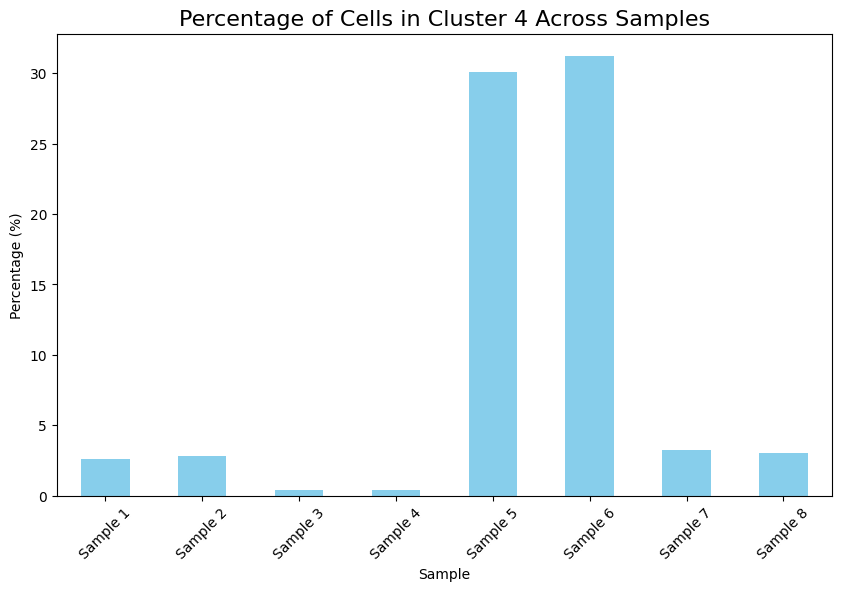

In [37]:
# Choose the cluster you want to visualize (e.g., cluster 1)
cluster_to_visualize = 4  # Example: Change this to the cluster you're interested in

# Filter the percentages DataFrame to include only the selected cluster
filtered_percentages_df = percentages_df.loc[cluster_to_visualize]

# Plot the percentage of cells in the selected cluster across samples
plt.figure(figsize=(10, 6))
filtered_percentages_df.plot(kind='bar', color='skyblue')
plt.title(f'Percentage of Cells in Cluster {cluster_to_visualize} Across Samples', fontsize=16)
plt.xlabel('Sample')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()


In [38]:
import pandas as pd

# Convert the dictionary to a DataFrame for better visualization
percentages_df = pd.DataFrame(cluster_percentages).fillna(0)

# Replace the index with the cluster labels
# Create a mapping for cluster numbers to labels
cluster_labels_df = pd.Series(cluster_labels)  # Convert the cluster_labels dict to a Series

# Replace the index (cluster numbers) with the corresponding cluster labels
percentages_df.index = percentages_df.index.map(cluster_labels_df)

# Display the percentage of cells in each cluster for each sample with labeled clusters
print(percentages_df)


                                 Sample 1  Sample 2  Sample 3  Sample 4  \
CD45+ others                        30.98     25.47     16.13     16.00   
CD3+CD38+ T                          3.40      2.97     41.00     42.88   
CD14+ Monocyte                      16.55     20.09     13.66     12.60   
CD33+CD11c+ mDC                      0.40      0.36      0.82      0.81   
CD33hiCD14+CD11c+CD47+ mono-AML      2.58      2.83      0.40      0.41   
CD45+ others                        15.19     17.46      1.80      2.00   
Un                                   5.59      6.62      4.60      3.96   
CD14hiCD33+CD11c+ Monocyte          14.06     13.27      0.00      0.01   
Un                                   3.04      2.91      4.01      4.16   
CD3+CD38- T                          0.78      0.57     12.81     12.39   
Un                                   6.66      6.74      2.50      2.27   
CD33+ myeloid                        0.05      0.05      0.08      0.13   
Un                       

In [40]:
# Convert the dictionary to a DataFrame for better visualization
percentages_df = pd.DataFrame(cluster_percentages).fillna(0)

# Replace the index with the cluster labels
# Create a mapping for cluster numbers to labels
cluster_labels_df = pd.Series(cluster_labels)  # Convert the cluster_labels dict to a Series

# Replace the index (cluster numbers) with the corresponding cluster labels
percentages_df.index = percentages_df.index.map(cluster_labels_df)

# Filter out the unwanted clusters, such as "Un" and "CD56+ others"
clusters_to_filter_out = ["Un", "CD45+ others"]  # Add any cluster labels you want to filter out
percentages_df_filtered = percentages_df[~percentages_df.index.isin(clusters_to_filter_out)]

# Display the percentage of cells in each cluster for each sample with labeled clusters
print(percentages_df_filtered)


                                 Sample 1  Sample 2  Sample 3  Sample 4  \
CD3+CD38+ T                          3.40      2.97     41.00     42.88   
CD14+ Monocyte                      16.55     20.09     13.66     12.60   
CD33+CD11c+ mDC                      0.40      0.36      0.82      0.81   
CD33hiCD14+CD11c+CD47+ mono-AML      2.58      2.83      0.40      0.41   
CD14hiCD33+CD11c+ Monocyte          14.06     13.27      0.00      0.01   
CD3+CD38- T                          0.78      0.57     12.81     12.39   
CD33+ myeloid                        0.05      0.05      0.08      0.13   
CD56hi NK                            0.21      0.17      0.01      0.02   

                                 Sample 5  Sample 6  Sample 7  Sample 8  
CD3+CD38+ T                          0.37      0.25     21.45     20.60  
CD14+ Monocyte                       0.21      0.10     14.63     13.91  
CD33+CD11c+ mDC                     35.01     35.42      1.24      1.40  
CD33hiCD14+CD11c+CD47+ mono-